In [121]:
import torch
import os
from pathlib import Path
import json
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from IPython.display import Audio, display
import random

In [122]:
METADATA_PATH = "/home/wyf/orcd/pool/diffrhythm/metadata.json"

with open(METADATA_PATH) as fin:
    metadata = json.load(fin)

clips = random.sample(metadata, 10)

In [123]:
from pprint import pprint
import librosa

for clip in clips:
    pprint(clip)

    y, sr = librosa.load(clip["full_audio_path"], sr=None)
    start_sample = int(clip["start_time"] * sr)
    end_sample = int(clip["end_time"] * sr)
    y_slice = y[start_sample:end_sample]
    display(Audio(y_slice, rate=sr))

{'activations_path': '/home/harinit9/orcd/pool/diffrhythm/activations/0002_chunk10.pt',
 'audio_path': '/home/harinit9/orcd/pool/diffrhythm/audio_chunks/0002_chunk10.wav',
 'chunk_id': '0002_chunk10',
 'chunk_index': 10,
 'duration': 5.0,
 'end_time': 55.0,
 'full_audio_path': '/home/harinit9/orcd/pool/diffrhythm/audio/0002.wav',
 'key_info': {'confidence': 0.8497395170793137,
              'error': None,
              'key': 'F_major',
              'mode': 'major',
              'note': 'F'},
 'label_key': 'F_major',
 'prompt': 'serene, minimalist piano, rolling arpeggios, slow',
 'start_time': 50.0}


{'activations_path': '/home/harinit9/orcd/pool/diffrhythm/activations/0014_chunk05.pt',
 'audio_path': '/home/harinit9/orcd/pool/diffrhythm/audio_chunks/0014_chunk05.wav',
 'chunk_id': '0014_chunk05',
 'chunk_index': 5,
 'duration': 5.0,
 'end_time': 30.0,
 'full_audio_path': '/home/harinit9/orcd/pool/diffrhythm/audio/0014.wav',
 'key_info': {'confidence': 0.917103232802936,
              'error': None,
              'key': 'F_major',
              'mode': 'major',
              'note': 'F'},
 'label_key': 'F_major',
 'prompt': 'piano, romantic era, heartfelt, featuring simple triads',
 'start_time': 25.0}


{'activations_path': '/home/harinit9/orcd/pool/diffrhythm/activations/0010_chunk04.pt',
 'audio_path': '/home/harinit9/orcd/pool/diffrhythm/audio_chunks/0010_chunk04.wav',
 'chunk_id': '0010_chunk04',
 'chunk_index': 4,
 'duration': 5.0,
 'end_time': 25.0,
 'full_audio_path': '/home/harinit9/orcd/pool/diffrhythm/audio/0010.wav',
 'key_info': {'confidence': 0.9796204892092674,
              'error': None,
              'key': 'F#_minor',
              'mode': 'minor',
              'note': 'F#'},
 'label_key': 'F#_minor',
 'prompt': 'steady upbeat piano piece, cinematic, ostinato pattern',
 'start_time': 20.0}


{'activations_path': '/home/harinit9/orcd/pool/diffrhythm/activations/0014_chunk07.pt',
 'audio_path': '/home/harinit9/orcd/pool/diffrhythm/audio_chunks/0014_chunk07.wav',
 'chunk_id': '0014_chunk07',
 'chunk_index': 7,
 'duration': 5.0,
 'end_time': 40.0,
 'full_audio_path': '/home/harinit9/orcd/pool/diffrhythm/audio/0014.wav',
 'key_info': {'confidence': 0.9237360549083098,
              'error': None,
              'key': 'F_major',
              'mode': 'major',
              'note': 'F'},
 'label_key': 'F_major',
 'prompt': 'piano, romantic era, heartfelt, featuring simple triads',
 'start_time': 35.0}


{'activations_path': '/home/harinit9/orcd/pool/diffrhythm/activations/0019_chunk06.pt',
 'audio_path': '/home/harinit9/orcd/pool/diffrhythm/audio_chunks/0019_chunk06.wav',
 'chunk_id': '0019_chunk06',
 'chunk_index': 6,
 'duration': 5.0,
 'end_time': 35.0,
 'full_audio_path': '/home/harinit9/orcd/pool/diffrhythm/audio/0019.wav',
 'key_info': {'confidence': 0.8989418204976172,
              'error': None,
              'key': 'D#_major',
              'mode': 'major',
              'note': 'D#'},
 'label_key': 'D#_major',
 'prompt': 'dreamy, chorale piano, block chords, medium tempo',
 'start_time': 30.0}


{'activations_path': '/home/harinit9/orcd/pool/diffrhythm/activations/0008_chunk18.pt',
 'audio_path': '/home/harinit9/orcd/pool/diffrhythm/audio_chunks/0008_chunk18.wav',
 'chunk_id': '0008_chunk18',
 'chunk_index': 18,
 'duration': 5.0,
 'end_time': 95.0,
 'full_audio_path': '/home/harinit9/orcd/pool/diffrhythm/audio/0008.wav',
 'key_info': {'confidence': 0.9506584789027758,
              'error': None,
              'key': 'A#_major',
              'mode': 'major',
              'note': 'A#'},
 'label_key': 'A#_major',
 'prompt': 'peaceful, romantic era piano, Alberti bass, slow',
 'start_time': 90.0}


{'activations_path': '/home/harinit9/orcd/pool/diffrhythm/activations/0021_chunk01.pt',
 'audio_path': '/home/harinit9/orcd/pool/diffrhythm/audio_chunks/0021_chunk01.wav',
 'chunk_id': '0021_chunk01',
 'chunk_index': 1,
 'duration': 5.0,
 'end_time': 10.0,
 'full_audio_path': '/home/harinit9/orcd/pool/diffrhythm/audio/0021.wav',
 'key_info': {'confidence': 0.969872010737443,
              'error': None,
              'key': 'A_major',
              'mode': 'major',
              'note': 'A'},
 'label_key': 'A_major',
 'prompt': 'bright, classical piano, pedal sustain, gentle',
 'start_time': 5.0}


{'activations_path': '/home/harinit9/orcd/pool/diffrhythm/activations/0014_chunk16.pt',
 'audio_path': '/home/harinit9/orcd/pool/diffrhythm/audio_chunks/0014_chunk16.wav',
 'chunk_id': '0014_chunk16',
 'chunk_index': 16,
 'duration': 5.0,
 'end_time': 85.0,
 'full_audio_path': '/home/harinit9/orcd/pool/diffrhythm/audio/0014.wav',
 'key_info': {'confidence': 0.9061846706982073,
              'error': None,
              'key': 'F_major',
              'mode': 'major',
              'note': 'F'},
 'label_key': 'F_major',
 'prompt': 'piano, romantic era, heartfelt, featuring simple triads',
 'start_time': 80.0}


{'activations_path': '/home/harinit9/orcd/pool/diffrhythm/activations/0004_chunk15.pt',
 'audio_path': '/home/harinit9/orcd/pool/diffrhythm/audio_chunks/0004_chunk15.wav',
 'chunk_id': '0004_chunk15',
 'chunk_index': 15,
 'duration': 5.0,
 'end_time': 80.0,
 'full_audio_path': '/home/harinit9/orcd/pool/diffrhythm/audio/0004.wav',
 'key_info': {'confidence': 0.9199022927499414,
              'error': None,
              'key': 'F#_minor',
              'mode': 'minor',
              'note': 'F#'},
 'label_key': 'F#_minor',
 'prompt': 'piano, romantic era, heartfelt, featuring simple triads',
 'start_time': 75.0}


{'activations_path': '/home/harinit9/orcd/pool/diffrhythm/activations/0019_chunk02.pt',
 'audio_path': '/home/harinit9/orcd/pool/diffrhythm/audio_chunks/0019_chunk02.wav',
 'chunk_id': '0019_chunk02',
 'chunk_index': 2,
 'duration': 5.0,
 'end_time': 15.0,
 'full_audio_path': '/home/harinit9/orcd/pool/diffrhythm/audio/0019.wav',
 'key_info': {'confidence': 0.8917740969882754,
              'error': None,
              'key': 'D#_major',
              'mode': 'major',
              'note': 'D#'},
 'label_key': 'D#_major',
 'prompt': 'dreamy, chorale piano, block chords, medium tempo',
 'start_time': 10.0}


In [124]:
acts = np.load("/home/wyf/orcd/pool/diffrhythm/acts_by_layer/layer_12.npy")
acts_pooled = np.max(acts, axis=1)
print(f"{acts.shape=}")
print(f"{acts_pooled.shape=}")

acts.shape=(399, 256, 2048)
acts_pooled.shape=(399, 2048)


In [125]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_pooled = scaler.fit_transform(acts_pooled)
print(f"{X_pooled.shape=}")

X_pooled.shape=(399, 2048)


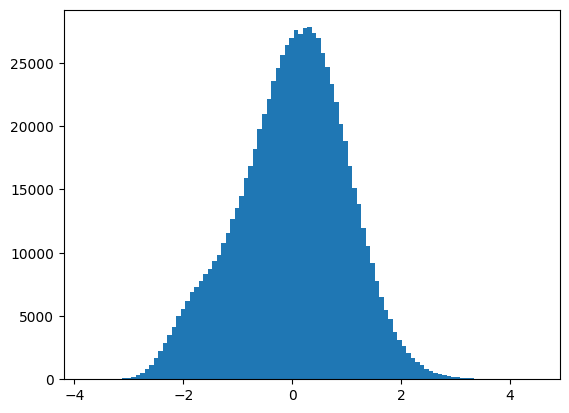

In [126]:
# Every feature should be normalized now
plt.hist(X_pooled[:].flatten(), bins=100);

In [127]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_pooled)
print(f"{X_pca.shape=}")

X_pca.shape=(399, 2)


/tmp/ipykernel_3909316/3113097192.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_labels))


Text(0.5, 1.0, 'PCA of Diffrhythm activations (layer 12) (colored by key)')

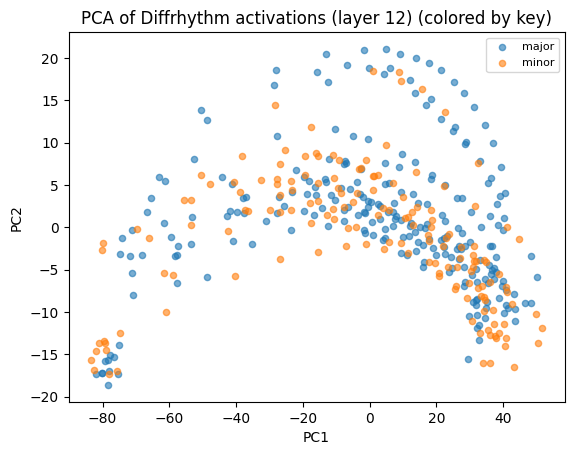

In [131]:
# Color by specific key
labels = np.array([clip["key_info"]["mode"] for clip in metadata[:len(X_pca)]])
unique_labels = np.unique(labels)

cmap = plt.cm.get_cmap("tab10", len(unique_labels))
for i, key in enumerate(unique_labels):
    mask = labels == key
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=key, alpha=0.6, s=20)
    
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(fontsize=8)
plt.title("PCA of Diffrhythm activations (layer 12) (colored by key)")
# plt.tight_layout()